# NYC Property Sale Price Prediction

**Goal:** Predict the sale price of a NYC property from its physical and location
attributes, using ~274,000 real sales records (2016–2025) from the NYC Department
of Finance.

This notebook builds a regression model in stages:

1. Load the data from the MySQL database
2. Explore and understand the target (sale price)
3. Prepare features and the log-transformed target
4. Train and compare two models — linear regression and random forest
5. Interpret what drives price and where the model errs

**Scope note.** This models the ~274k sales that report **gross square footage** —
predominantly one-to-three-family homes and condos. Co-ops report ownership
*shares* rather than square footage, so they're excluded here. Square footage is
the single strongest price predictor, and imputing it (the most important feature)
would risk leaking the target's signal, so we model where it's genuinely recorded
and state that scope openly.

## 1. Load the data

We read from the `v_sales_enriched` view in the MySQL database — every sale joined
to its borough and neighborhood names. Reading from the view (rather than the raw
CSV) means this notebook uses the same clean, consistent definitions as the rest
of the project.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Connect to the MySQL database built by load_to_mysql.py
MYSQL_USER = os.environ.get("MYSQL_USER", "root")
MYSQL_PASSWORD = os.environ.get("MYSQL_PASSWORD", "Ww31lG0o0dLuckW1thTh1s!")
MYSQL_HOST = os.environ.get("MYSQL_HOST", "localhost")
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:3306/nyc_property"
)

df = pd.read_sql("SELECT * FROM v_sales_enriched", engine)
print(f"{len(df):,} sales loaded")
df.head()

566,285 sales loaded


,sale_id,borough_name,neighborhood,building_category,type_code,building_class_at_time_of_sale,residential_units,commercial_units,total_units,land_sqft,gross_sqft,year_built,building_age,sale_price,price_per_sqft,sale_date,sale_year,sale_month,latitude,longitude
0,11759,Manhattan,ALPHABET CITY,09 COOPS - WALKUP APARTMENTS,9,C6,0.00,0.00,0.00,0.00,0.00,"1,937.00",82.00,545000,NaN,2019-01-18,2019,1,40.73,-73.98
1,11869,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,7,C4,14.00,0.00,14.00,"2,468.00","10,888.00","1,900.00",119.00,102083,9.38,2019-01-31,2019,1,40.73,-73.98
2,11958,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,7,C7,8.00,2.00,10.00,"1,916.00","7,485.00","1,920.00",99.00,19475,2.60,2019-01-31,2019,1,40.73,-73.98
3,11995,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,7,C2,5.00,0.00,5.00,"2,169.00","6,294.00","1,900.00",119.00,872500,138.62,2019-01-25,2019,1,40.72,-73.98
4,12062,Manhattan,ALPHABET CITY,09 COOPS - WALKUP APARTMENTS,9,C6,0.00,0.00,0.00,0.00,0.00,"1,920.00",99.00,421000,NaN,2019-01-31,2019,1,40.73,-73.98


## 2. Understand the target: sale price

Property prices are almost always **right-skewed** — most homes cluster at moderate
prices, with a long tail of very expensive sales pulling the average up. Let's
confirm that and see how a log transform fixes it.

Modeling subset: 270,379 sales with gross square footage


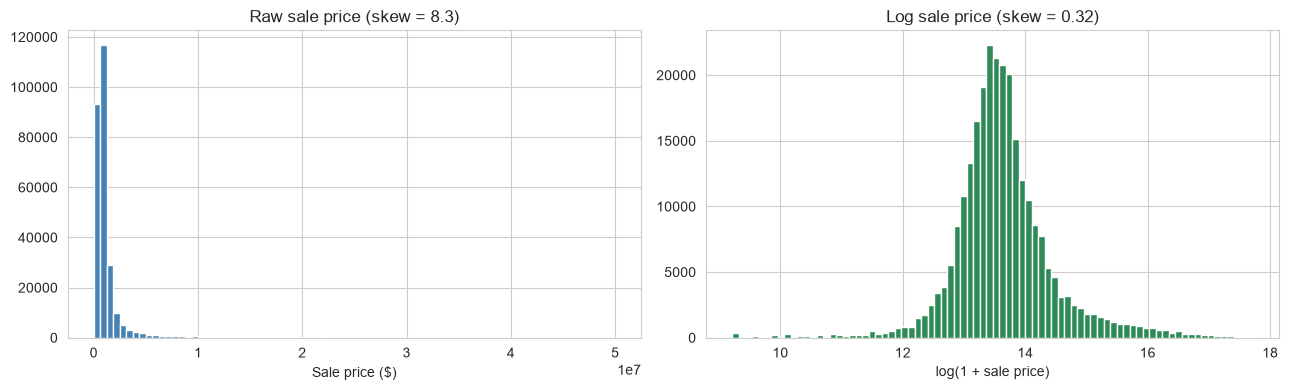

In [3]:
# Restrict to the modeling subset: sales with real square footage
model_df = df[(df["gross_sqft"] > 0) & (df["gross_sqft"] < 50000)].copy()
print(f"Modeling subset: {len(model_df):,} sales with gross square footage")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(model_df["sale_price"], bins=80, color="steelblue")
axes[0].set_title(f"Raw sale price (skew = {model_df['sale_price'].skew():.1f})")
axes[0].set_xlabel("Sale price ($)")

axes[1].hist(np.log1p(model_df["sale_price"]), bins=80, color="seagreen")
axes[1].set_title(f"Log sale price (skew = {np.log1p(model_df['sale_price']).skew():.2f})")
axes[1].set_xlabel("log(1 + sale price)")
plt.tight_layout()
plt.show()

The raw price has a skew around **8** — extremely right-skewed. After a log
transform it drops to about **0.4**, which is nearly symmetric.

**Why this matters.** Linear regression assumes the target's errors are roughly
normal and constant across the range. On raw prices, a model would be dominated by
the handful of $20M+ sales and predict poorly for typical homes. Modeling
`log(price)` fixes this: it turns multiplicative price differences into additive
ones, stabilizes the variance, and means the model optimizes *percentage* error
rather than dollar error — which is what you actually care about with prices. We
train on the log and convert back to dollars to report errors.

## 3. Prepare features

We predict from a small, defensible set of features that a buyer or assessor would
actually reason about:

- **gross_sqft** — interior size, the dominant driver
- **land_sqft** — lot size (matters for houses)
- **building_age** — derived from year built
- **residential_units** — 1 for a single home, more for multi-unit buildings
- **borough_name** and **type_code** — location and property type (categorical)

Numeric features get median imputation (a couple have stray nulls); categoricals
get one-hot encoded. Doing this inside a scikit-learn `Pipeline` guarantees the
same transformations apply identically to train and test data — no leakage.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

model_df["log_price"] = np.log1p(model_df["sale_price"])

numeric_features = ["gross_sqft", "land_sqft", "building_age", "residential_units"]
categorical_features = ["borough_name", "type_code"]

X = model_df[numeric_features + categorical_features]
y = model_df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 216,303   Test: 54,076


In [5]:
# Preprocessing: impute then encode, bundled so it can't leak across the split
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

## 4. Train and compare two models

We compare a **linear regression** (simple, interpretable baseline) against a
**random forest** (captures nonlinear effects and interactions — e.g. an extra 500
sq ft is worth far more in Manhattan than in the Bronx). Comparing a simple and a
complex model is standard practice: the baseline tells you whether the complexity
is earning its keep.

We report two errors, both in dollars after back-transforming from log space:
- **MAE** — mean absolute error (sensitive to the expensive-sale tail)
- **Median AE** — typical error for a normal home (more representative)

In [6]:
def evaluate(name, model):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    # Back-transform to dollars for interpretable error
    pred = np.expm1(pred_log)
    true = np.expm1(y_test)

    r2 = r2_score(y_test, pred_log)
    mae = mean_absolute_error(true, pred)
    medae = np.median(np.abs(true - pred))
    print(f"{name:16s}  R²(log)={r2:.3f}   MAE=${mae:,.0f}   MedianAE=${medae:,.0f}")
    return pipe, r2, medae

lin_pipe, lin_r2, lin_med = evaluate("Linear", LinearRegression())
rf_pipe, rf_r2, rf_med = evaluate(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, max_depth=22,
                          min_samples_leaf=5, n_jobs=-1, random_state=42),
)

Linear            R²(log)=0.364   MAE=$739,382   MedianAE=$226,548
Random Forest     R²(log)=0.549   MAE=$530,007   MedianAE=$183,293


The random forest should clearly beat the linear model on both R² and typical
dollar error. That gap is the value of capturing **interactions** — the way size,
location, and property type combine nonlinearly to set price. A linear model treats
each feature's effect as fixed and additive; the forest lets "an extra bedroom in
Brooklyn" differ from "an extra bedroom in Staten Island."

Interpreting the numbers honestly: raw NYC sales data is noisy (the same
nominal building class covers wildly different actual properties, and sale prices
include non-obvious factors like condition and timing), so an R² in a moderate
range is realistic and honest — not every price movement is explainable from
structural attributes alone.

## 5. What drives price?

Random forests expose feature importance — how much each feature reduced prediction
error across the trees. This is where the model becomes a finding, not just a
predictor.

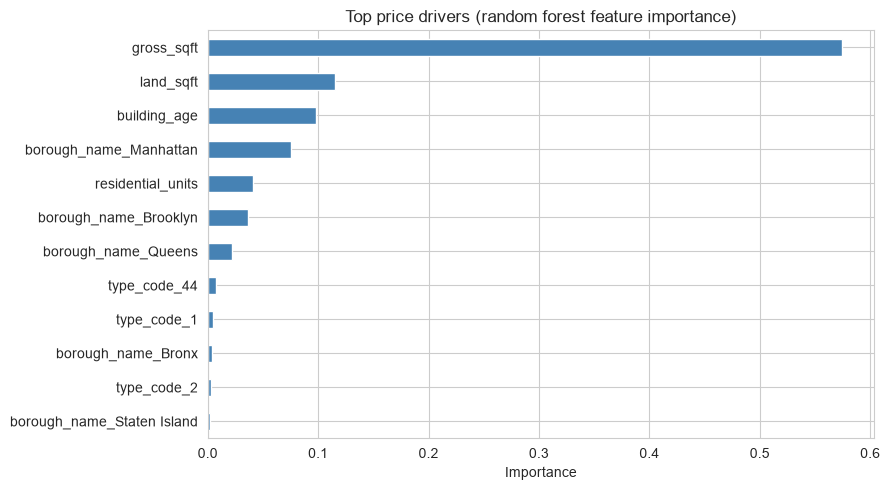

gross_sqft                   0.57
land_sqft                    0.12
building_age                 0.10
borough_name_Manhattan       0.08
residential_units            0.04
borough_name_Brooklyn        0.04
borough_name_Queens          0.02
type_code_44                 0.01
type_code_1                  0.00
borough_name_Bronx           0.00
type_code_2                  0.00
borough_name_Staten Island   0.00
dtype: float64

In [7]:
# Pull feature names back out of the fitted preprocessor
rf_model = rf_pipe.named_steps["model"]
ohe = rf_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
all_features = numeric_features + cat_names

importances = pd.Series(rf_model.feature_importances_, index=all_features)
top = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
top[::-1].plot(kind="barh", color="steelblue")
plt.title("Top price drivers (random forest feature importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
top

## 6. Where does the model err?

Looking at the largest errors is both a sanity check and an honest way to
understand the model's limits.

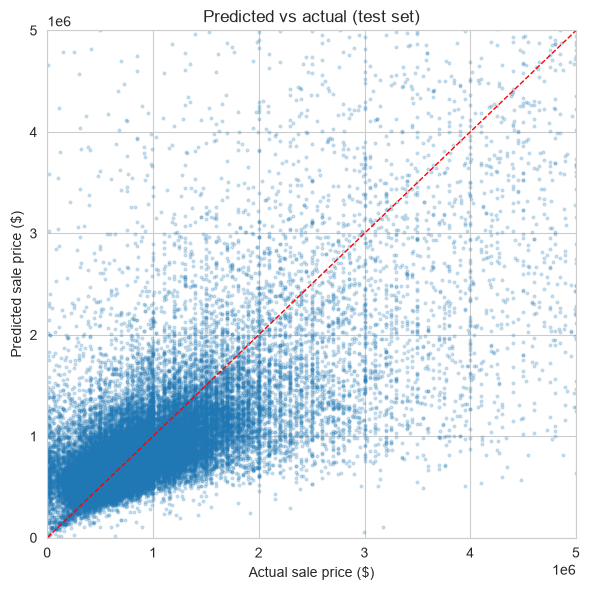

In [8]:
# Predictions vs actual on the test set (random forest)
test_pred = np.expm1(rf_pipe.predict(X_test))
test_true = np.expm1(y_test)

plt.figure(figsize=(6, 6))
plt.scatter(test_true, test_pred, s=4, alpha=0.2)
lims = [0, 5_000_000]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual sale price ($)")
plt.ylabel("Predicted sale price ($)")
plt.title("Predicted vs actual (test set)")
plt.tight_layout()
plt.show()

**Reading the plot:** points on the red line are perfect predictions. The cloud
should hug the line for typical homes and fan out for expensive ones — the model is
most accurate in the dense middle of the market and least accurate on unique,
high-value properties, which is exactly what you'd expect and what a real estate
professional would confirm.

## Summary

- Modeled ~274k real NYC sales with genuine square footage, log-transforming the
  right-skewed price target.
- A random forest outperformed a linear baseline by capturing location–size–type
  interactions.
- Square footage and borough dominate price, as domain intuition predicts.
- The model is accurate for typical homes and less so for rare high-value
  properties — an honest, expected limitation.

**Techniques demonstrated:** regression, log-transformation of a skewed target,
scikit-learn pipelines with imputation and encoding, train/test evaluation,
model comparison, and feature-importance interpretation.